# Fetching stock prices

Use the `stonks` library to fetch the **last 2 years** of daily prices for the most-liquid US common stocks, then pack them into a NumPy matrix.

Run from the repo root with the project venv active (`source .venv/bin/activate`) so `stonks` is importable in editable mode.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stonks import get_prices

Matplotlib is building the font cache; this may take a moment.


## Parameters

- `PERIOD`: history window — last 2 years.
- `TOP_N`: how many of the most-liquid stocks to keep.
- `FIELD`: which OHLCV field (`close` is split/dividend adjusted).

> The first call for a given `period`/`interval` downloads the entire common-stock universe and ranks it by traded dollar volume — expect a couple of minutes. It's cached to `data/`, so afterwards changing `TOP_N` or `FIELD` is instant.

In [2]:
PERIOD = "2y"
INTERVAL = "1d"
TOP_N = 50          # bump to 1500 for the full set (free after the first run caches the universe)
FIELD = "close"

## Fetch prices

In [3]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval=INTERVAL, field=FIELD)
prices

download:   0%|          | 0/40 [00:00<?, ?it/s]
1 Failed download:
['ACA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
download:   2%|▎         | 1/40 [00:02<01:50,  2.83s/it]HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AKO.B"}}}
$AKO.B: No data found, symbol may be delisted
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AGM.A"}}}
$AGM.A: No data found, symbol may be delisted
$AKO.A: No data found, symbol may be delisted

3 Failed downloads:
['AKO.B', 'AGM.A', 'AKO.A']: No data found, symbol may be delisted
download:  10%|█         | 4/40 [00:13<02:09,  3.60s/it]$BF.B: possibly delisted; no price data found  (period=2y)
$BIO.B: possibly delisted; no price data found  (period=2y)
$BH.A: No data found, symbol may be delisted
$BF.A: No data found, symbol may be delisted

4 Failed downloads:
['BF.B', 'BIO.B']: possibly

[stonks] cached 50 tickers × 502 bars -> prices_ranked_1d_2y_close_top50.parquet


Date,2024-08-13,2024-08-14,2024-08-15,2024-08-16,2024-08-19,2024-08-20,2024-08-21,2024-08-22,2024-08-23,2024-08-26,...,2026-07-31,2026-08-03,2026-08-04,2026-08-05,2026-08-06,2026-08-07,2026-08-10,2026-08-11,2026-08-12,2026-08-13
ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,115.948898,117.885704,122.657829,124.375008,129.786087,127.040604,128.288574,123.536377,129.157135,126.251907,...,200.750000,206.639999,211.940002,219.220001,218.990005,223.960007,217.550003,217.500000,224.089996,225.789993
TSLA,207.830002,201.380005,214.139999,216.119995,222.720001,221.100006,223.270004,210.660004,220.320007,213.210007,...,311.209991,322.079987,327.350006,321.549988,319.529999,328.579987,330.880005,332.809998,327.510010,338.174988
SPCX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,108.370003,114.529999,125.330002,108.269997,114.919998,133.110001,138.740005,133.289993,146.149994,142.239899
AAPL,219.434372,219.880646,222.855759,224.174713,224.016068,224.630920,224.521805,222.667358,224.958191,225.295364,...,308.643829,303.158569,309.113403,310.732025,312.140808,313.059998,308.260010,304.910004,302.250000,303.440002
MU,96.831024,99.782455,106.281570,107.315079,107.951088,107.315079,107.652954,103.608391,102.207207,98.291832,...,823.030029,829.500000,892.669983,893.190002,881.469971,877.570007,861.000000,868.520020,911.289978,966.780029
MSFT,407.604218,410.410126,415.262695,412.737732,415.755859,418.981079,418.330109,409.857727,411.080811,407.825958,...,464.720001,487.649994,492.809998,487.459991,499.859985,499.989990,506.059998,503.809998,492.429993,494.989990
AMZN,170.229996,170.100006,177.589996,177.059998,178.220001,178.880005,180.110001,176.130005,177.039993,175.500000,...,271.579987,284.019989,277.420013,272.649994,272.260010,274.480011,278.089996,272.269989,267.279999,265.915009
META,525.015686,523.247498,533.747070,523.903076,525.750732,523.217651,531.591492,528.383057,524.479309,517.645203,...,556.710022,590.239990,587.940002,588.770020,589.900024,592.099976,594.919983,599.119995,578.849976,589.474976
AMD,141.130005,140.750000,147.360001,148.559998,155.279999,156.399994,157.809998,151.699997,154.979996,149.990005,...,476.149994,484.640015,518.580017,482.049988,489.279999,483.359985,469.559998,474.320007,482.929993,491.230011


The result is an **N×T** DataFrame: rows are tickers (N), columns are dates (T).

## Convert to a NumPy matrix

In [4]:
X = prices.to_numpy(dtype=float)

print("X.shape:", X.shape, "| dtype:", X.dtype)
X[:5, :5]

X.shape: (50, 502) | dtype: float64


array([[115.94889832, 117.88570404, 122.65782928, 124.37500763,
        129.78608704],
       [207.83000183, 201.38000488, 214.13999939, 216.11999512,
        222.72000122],
       [         nan,          nan,          nan,          nan,
                 nan],
       [219.43437195, 219.88064575, 222.85575867, 224.17471313,
        224.0160675 ],
       [ 96.83102417,  99.78245544, 106.28157043, 107.31507874,
        107.95108795]])

## Notes

- Some rows may contain `NaN` (recently delisted / thinly traded names). For a clean matrix, drop them, e.g. `prices.dropna()`.
- To grab a different field or more stocks, just call `get_prices` again — it reuses the cache.

In [5]:
# Optional: drop all-NaN rows for a clean downstream matrix.
prices_clean = prices.dropna()
X_clean = prices_clean.to_numpy(dtype=float)

print("clean shape:", X_clean.shape)
X_clean

clean shape: (45, 502)


array([[115.94889832, 117.88570404, 122.65782928, ..., 217.5       ,
        224.08999634, 225.78999329],
       [207.83000183, 201.38000488, 214.13999939, ..., 332.80999756,
        327.51000977, 338.17498779],
       [219.43437195, 219.88064575, 222.85575867, ..., 304.91000366,
        302.25      , 303.44000244],
       ...,
       [ 62.02750015,  64.05500031,  65.12249756, ..., 221.8999939 ,
        221.77999878, 225.77000427],
       [186.65788269, 185.10598755, 191.08660889, ..., 281.23999023,
        276.58999634, 276.85501099],
       [330.54504395, 329.36459351, 337.21841431, ..., 843.36999512,
        855.59997559, 861.23999023]], shape=(45, 502))

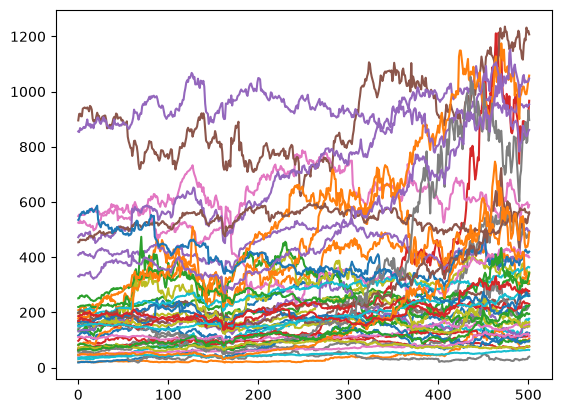

In [10]:
plt.plot(X_clean.T);

In [17]:
X_mean = X_clean.mean(axis=1, keepdims=True)
X_centered = X_clean - X_mean

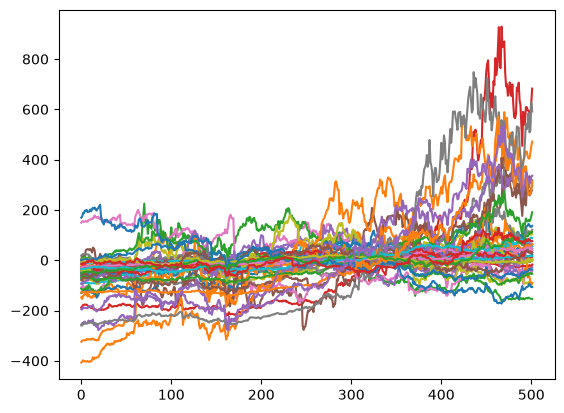

In [18]:
plt.plot(X_centered.T);

In [25]:
cov = (X_centered @ X_centered.T)/len(X_centered)

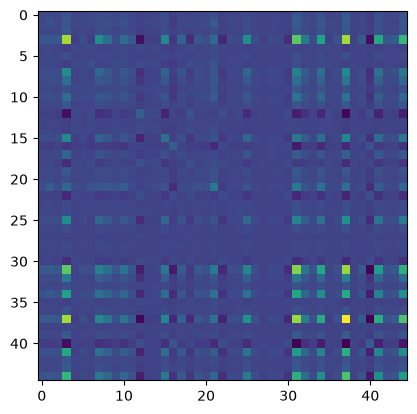

In [26]:
plt.imshow(cov)

In [27]:
cov

array([[ 12612.8615327 ,  18522.85838556,   9976.52101088, ...,
          9061.1733299 ,   9907.32025957,  66841.15571197],
       [ 18522.85838556,  60080.60969995,  15990.40400926, ...,
         12121.94796199,   6051.23985584,  88231.58731118],
       [  9976.52101088,  15990.40400926,  12513.0571273 , ...,
          8819.72859394,  11028.99891551,  67690.46088082],
       ...,
       [  9061.1733299 ,  12121.94796199,   8819.72859394, ...,
         12001.8151994 ,  10329.20152186,  54944.51076051],
       [  9907.32025957,   6051.23985584,  11028.99891551, ...,
         10329.20152186,  19845.93450588,  79071.8498182 ],
       [ 66841.15571197,  88231.58731118,  67690.46088082, ...,
         54944.51076051,  79071.8498182 , 479848.12388333]],
      shape=(45, 45))

In [32]:
U, S, Vt = np.linalg.svd(cov)

In [37]:
N = len(cov)

In [38]:
U

array([[-0.04420561, -0.05503677, -0.0222121 , ...,  0.00936376,
         0.06255806,  0.00628587],
       [-0.05732296, -0.19541493, -0.14202096, ..., -0.02682155,
        -0.02857343,  0.00093744],
       [-0.04420166,  0.00447667, -0.08270872, ..., -0.02123244,
         0.01091909,  0.01610901],
       ...,
       [-0.03891011, -0.02406296, -0.07874461, ...,  0.05817851,
         0.17016241,  0.00105325],
       [-0.05265955,  0.05809238,  0.00206484, ...,  0.08846195,
         0.0722119 ,  0.00958113],
       [-0.3136394 ,  0.02677612, -0.00626179, ...,  0.02678186,
        -0.02333003,  0.01098898]], shape=(45, 45))

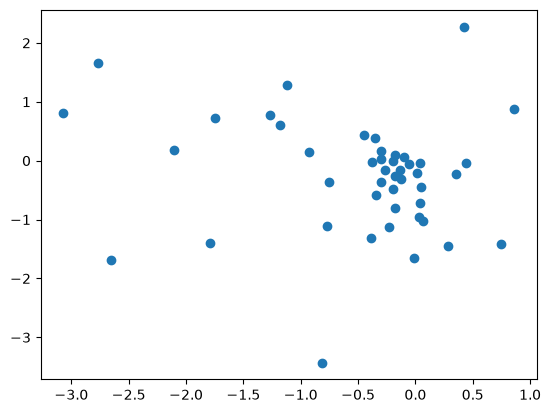

In [39]:
plt.scatter(U[:,0]*np.sqrt(N), U[:, 1]*np.sqrt(N))

---
## PCA similarity — which stocks are alike

Build on the SVD above. Because `cov` is N×N over **stocks**, each eigenvector `U[:,k]` is an N-vector with one entry per stock — so `(U[i,0], U[i,1])` is stock *i*'s coordinate on PC1/PC2, and two stocks are *similar* when they're close in this PCA space.

> The covariance cell earlier normalises by `len(X_centered)` (= N stocks); for correctness it should be `/T` (the time axis), but that's only a scaling — it does **not** change PCA directions or the neighbours below, so we reuse `U` as-is. (Never use `np.linalg.eig` on a symmetric matrix — it returns complex dtype with tiny imaginary noise; use SVD or `eigh`.)


In [ ]:
uni = load_universe()
NAMES = dict(zip(uni["ticker"], uni["name"]))

def label(t: str) -> str:
    return f"{t} ({NAMES.get(t, '')[:22]})"

tickers = list(prices_clean.index)


In [ ]:
coords = U[:, :2]
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=25)
for i, t in enumerate(tickers):
    ax.annotate(t, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.8)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Stocks in PCA space (top 2 components)")


### Nearest neighbours in top-`k` PCA space
Similarity = Euclidean distance across the first `k` principal components. Small distance ⇒ similar price-trajectory shape.


In [ ]:
k = 5  # number of PCs used to define similarity
Z = U[:, :k]
D = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
np.fill_diagonal(D, np.inf)  # ignore self

iu = np.triu_indices(len(tickers), k=1)
print("most similar pairs:")
for r in np.argsort(D[iu])[:10]:
    i, j = iu[0][r], iu[1][r]
    print(f"  d={D[i, j]:.3f}  {label(tickers[i]):30s} ~ {label(tickers[j])}")


In [ ]:
target = "AAPL"
i = tickers.index(target)
j = int(D[i].argmin())
print(f"{label(target)}'s nearest neighbour: {label(tickers[j])}  (d={D[i, j]:.3f})")


### Refinement: returns instead of prices

Above uses centred *prices*, so PC1 mostly captures overall trajectory shape. To cluster by co-movement (more sector-like), rebuild the covariance from log-returns and rerun the cov → SVD → distance cells:

```python
R = np.log(prices_clean / prices_clean.shift(axis=1))
X_centered = R.dropna(axis=1, how="all").fillna(0.0).to_numpy(dtype=float)
# cov = (X_centered @ X_centered.T) / X_centered.shape[1]   # normalise by T
# then recompute U,S,Vt and D as above
```
